# 📊 Deep Research — Pairwise Report Evaluation for the domain `NLP`

This notebook evaluates **all pairwise combinations** of the four config reports for the same research question using **YESciEval pairwise rubrics**.

### Steps
1. Read the research **question from the domain CSV** (shared by all reports)
2. Load **all four config reports** from the report pool
3. Enumerate all **C(4,2) = 6 config pairs** automatically
4. For each pair — run the YESciEval pairwise judge across all rubrics
5. Aggregate rubric scores → **category-level scores for A and B**
6. Display a **6-panel grouped comparison plot** per pair
7. Save JSON + CSV outputs per pair

---
**Prerequisites:** `pip install yescieval python-dotenv matplotlib numpy`

## 1 — Imports & Setup

In [5]:
!pip install yescieval==0.10.0 python-dotenv matplotlib 

In [6]:
import re, json, csv, itertools
from pathlib import Path
from typing import Dict, Tuple, List
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
from dotenv import load_dotenv
import torch
load_dotenv()
print("✅ Core imports loaded")

✅ Core imports loaded


In [7]:
# Pairwise rubric classes — same names as pointwise but from the pairwise subpackage
from yescieval import CustomAutoJudge, VocabularyInjector, ExampleInjector
from yescieval.rubric.pairwise.depth      import TemporalPrecision, CausalReasoning, MechanisticUnderstanding
from yescieval.rubric.pairwise.breadth    import ContextCoverage, ScopeCoverage, DimensionCoverage, ScaleCoverage, MethodCoverage
from yescieval.rubric.pairwise.rigor      import EpistemicCalibration, ExplicitUncertainty, QuantitativeEvidenceAndUncertainty
# from yescieval.rubric.pairwise.innovation import StateOfTheArtAndNovelty
# from yescieval.rubric.pairwise.gap        import GapIdentification
print("✅ YESciEval pairwise imports loaded")

✅ YESciEval pairwise imports loaded


## 2 — Configuration

Set the domain, model, and populate the report pool. All C(4,2) = 6 pairs are evaluated automatically.

In [8]:
# --- USER CONFIGURATION ---

QUESTIONS_CSV  = "/nfs/home/gillm/deep-research/data/nlp/49-questions-nlp.csv"
OUTPUT_DIR     = "/nfs/home/gillm/deep-research/eval/output"
DOMAIN         = "nlp"          
MODEL_ID       = "Qwen/Qwen3-8B"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(DEVICE)           
HF_TOKEN       = "your-hf-token"
MAX_NEW_TOKENS = 2048

# ── Report pool ──────────────────────────────────────────────────────────────
# Map every config to its report file. All C(4,2) = 6 pairs will be evaluated.
REPORT_POOL = {
    'd1_b1': '/nfs/home/gillm/deep-research/data/nlp/reports/orkg-ask/o3-mini/1_o3-mini_orkg_d1_b1.md',
    'd1_b4': '/nfs/home/gillm/deep-research/data/nlp/reports/orkg-ask/o3-mini/1_o3-mini_orkg_d1_b4.md',
    'd4_b1': '/nfs/home/gillm/deep-research/data/nlp/reports/orkg-ask/o3-mini/1_o3-mini_orkg_d4_b1.md',
    'd4_b4': '/nfs/home/gillm/deep-research/data/nlp/reports/orkg-ask/o3-mini/1_o3-mini_orkg_d4_b4.md',
}

# ── All pairs are generated automatically — no manual selection needed ────────
ALL_PAIRS = list(itertools.combinations(REPORT_POOL.keys(), 2))
# → [('d1_b1','d1_b4'), ('d1_b1','d4_b1'), ('d1_b1','d4_b4'),
#    ('d1_b4','d4_b1'), ('d1_b4','d4_b4'), ('d4_b1','d4_b4')]

# Category → list of (RubricClass, weight) tuples
CATEGORIES: Dict[str, List[Tuple[type, float]]] = {
    "depth": [
        (TemporalPrecision,         1/3),
        (CausalReasoning,           1/3),
        (MechanisticUnderstanding,  1/3),
    ],
    "breadth": [
        (ContextCoverage,   1/5),
        (ScopeCoverage,     1/5),
        (DimensionCoverage, 1/5),
        (MethodCoverage,    1/5),
        (ScaleCoverage,     1/5),
    ],
    "rigor": [
        (EpistemicCalibration,               1/3),
        (ExplicitUncertainty,                1/3),
        (QuantitativeEvidenceAndUncertainty, 1/3),
    ],
    # "innovation": [
    #     (StateOfTheArtAndNovelty, 1.0),
    # ],
    # "gap": [
    #     (GapIdentification, 1.0),
    # ],
}

RATING_MIN, RATING_MAX = 1, 5

print(f"Report pool : {list(REPORT_POOL.keys())}")
print(f"Pairs to run: {len(ALL_PAIRS)} — {ALL_PAIRS}")
print(f"Model       : {MODEL_ID}")
print(f"Categories  : {list(CATEGORIES.keys())}")

cuda
Report pool : ['d1_b1', 'd1_b4', 'd4_b1', 'd4_b4']
Pairs to run: 6 — [('d1_b1', 'd1_b4'), ('d1_b1', 'd4_b1'), ('d1_b1', 'd4_b4'), ('d1_b4', 'd4_b1'), ('d1_b4', 'd4_b4'), ('d4_b1', 'd4_b4')]
Model       : Qwen/Qwen3-8B
Categories  : ['depth', 'breadth', 'rigor']


## 3 — Helper Functions

In [9]:
def parse_config(stem: str) -> str:
    """Extracts dX_bY from filename, e.g. 1_o3-mini_orkg_d1_b1 -> d1_b1."""
    m = re.search(r'd(\d+)_b(\d+)', stem)
    return f"d{m.group(1)}_b{m.group(2)}" if m else 'd1_b1'


def parse_report_number(stem: str) -> int:
    """Extracts the leading report number from filename, e.g. 1_o3-mini -> 1."""
    m = re.match(r'(\d+)[_\-]', stem)
    return int(m.group(1)) if m else -1


def load_question_from_csv(csv_path: str, report_number: int) -> str:
    """
    Reads the report title by ROW POSITION (1-based) from the NLP CSV.
    The NLP CSV uses a 'title' column (vs ecology's 'Your research question.' column).
    All reports share the same question; row is derived from the first pool entry.
    """
    encodings_to_try = ['cp1252', 'utf-8', 'utf-8-sig', 'latin-1']
    for encoding in encodings_to_try:
        try:
            with open(csv_path, newline='', encoding=encoding) as f:
                reader = csv.DictReader(f)
                for row_num, row in enumerate(reader, start=1):
                    if row_num == report_number:
                        q = row.get('title', '').strip()
                        return q if q else f'Empty title at row {report_number}'
            return f'Row {report_number} not found in CSV (file has fewer rows)'
        except UnicodeDecodeError:
            continue
    return 'Could not open CSV with any known encoding'


def parse_pairwise_judge_result(result, rubric_name: str) -> Tuple[int, int, str, str]:
    """
    Extracts (rating_a, rating_b, rationale_a, rationale_b) from a pairwise judge result.

    Expected JSON shape:
    {
        "RubricName": {
            "ResponseA": {"rating": 4, "rationale": "..."},
            "ResponseB": {"rating": 3, "rationale": "..."}
        }
    }
    """
    if isinstance(result, str):
        cleaned = re.sub(r'<think>.*?</think>', '', result, flags=re.DOTALL).strip()
        json_str = None
        depth, start = 0, None
        for i, ch in enumerate(cleaned):
            if ch == '{':
                if depth == 0: start = i
                depth += 1
            elif ch == '}':
                depth -= 1
                if depth == 0 and start is not None:
                    json_str = cleaned[start:i+1]
                    break
        if json_str:
            try:
                result = json.loads(json_str)
            except json.JSONDecodeError:
                pass
        if isinstance(result, str):
            return 0, 0, '', result

    if isinstance(result, dict):
        inner = result.get(rubric_name) or result.get(rubric_name.lower())
        if inner is None and len(result) == 1:
            inner = next(iter(result.values()))
        if isinstance(inner, dict):
            resp_a = inner.get('ResponseA', {})
            resp_b = inner.get('ResponseB', {})
            return (
                int(resp_a.get('rating',    0)),
                int(resp_b.get('rating',    0)),
                str(resp_a.get('rationale', '')),
                str(resp_b.get('rationale', '')),
            )
        if 'ResponseA' in result:
            resp_a = result['ResponseA']
            resp_b = result.get('ResponseB', {})
            return (
                int(resp_a.get('rating',    0)),
                int(resp_b.get('rating',    0)),
                str(resp_a.get('rationale', '')),
                str(resp_b.get('rationale', '')),
            )
        return 0, 0, '', str(result)

    if hasattr(result, 'ResponseA') and hasattr(result, 'ResponseB'):
        resp_a = result.ResponseA
        resp_b = result.ResponseB
        return (
            int(getattr(resp_a, 'rating',    0)),
            int(getattr(resp_b, 'rating',    0)),
            str(getattr(resp_a, 'rationale', '')),
            str(getattr(resp_b, 'rationale', '')),
        )
    return 0, 0, '', str(result)


def compute_category_score(rubric_scores: List[Tuple[float, float]]) -> float:
    """
    Weighted mean of (score, weight) pairs, normalised to 0.0-1.0.
    Formula: (weighted_mean - 1) / (5 - 1)
    """
    total_w = sum(w for _, w in rubric_scores)
    if not total_w:
        return 0.0
    weighted_mean = sum(s * w for s, w in rubric_scores) / total_w
    return round((weighted_mean - 1) / (RATING_MAX - RATING_MIN), 4)


def run_pair(cfg_a, cfg_b, report_a_md, report_b_md, question, judge):
    """
    Runs the full pairwise evaluation for one (cfg_a, cfg_b) combination.
    Returns (rubric_raw, category_scores, overall_a, overall_b).
    """
    rubric_raw:      Dict[str, dict]             = {}
    category_scores: Dict[str, Dict[str, float]] = {}

    for cat_name, rubric_list in CATEGORIES.items():
        print(f"  📂 {cat_name.upper()}")
        cat_rubric_a: List[Tuple[float, float]] = []
        cat_rubric_b: List[Tuple[float, float]] = []

        for RubricClass, weight in rubric_list:
            rname = RubricClass.__name__
            print(f"     🔎 [{rname}] (w={weight:.3f}) ...")
            rubric = RubricClass(
                papers={},
                question=question,
                answer_a=report_a_md,
                answer_b=report_b_md,
                domain=DOMAIN,
                vocabulary=VocabularyInjector(),
                example=ExampleInjector(),
            )
            raw = judge.judge(rubric=rubric, max_new_tokens=MAX_NEW_TOKENS)
            rating_a, rating_b, rat_a, rat_b = parse_pairwise_judge_result(raw, rname)
            rubric_raw[rname] = {
                'ResponseA': {'rating': rating_a, 'rationale': rat_a},
                'ResponseB': {'rating': rating_b, 'rationale': rat_b},
                'weight_in': {cat_name: weight},
            }
            print(f"        ResponseA={rating_a}/5  |  ResponseB={rating_b}/5")
            cat_rubric_a.append((float(rating_a), weight))
            cat_rubric_b.append((float(rating_b), weight))

        score_a = compute_category_score(cat_rubric_a)
        score_b = compute_category_score(cat_rubric_b)
        category_scores[cat_name] = {'a': score_a, 'b': score_b}
        print(f"     ✅ {cat_name}  {cfg_a}={score_a:.2f}  {cfg_b}={score_b:.2f}")

    overall_a = round(sum(v['a'] for v in category_scores.values()) / len(category_scores), 4)
    overall_b = round(sum(v['b'] for v in category_scores.values()) / len(category_scores), 4)
    return rubric_raw, category_scores, overall_a, overall_b

print("✅ Helpers defined")

✅ Helpers defined


## 4 — Load All Reports & Read Question from CSV

In [10]:
# Load all reports from the pool upfront
loaded_reports: Dict[str, str] = {}
for cfg, path in REPORT_POOL.items():
    p = Path(path).resolve()
    if not p.exists():
        raise FileNotFoundError(f'Report not found for {cfg}: {p}')
    loaded_reports[cfg] = p.read_text(encoding='utf-8', errors='ignore')
    print(f"✅ {cfg}: {p.name}  ({len(loaded_reports[cfg]):,} chars)")

# Derive the question row from the first pool entry's filename
first_stem = Path(next(iter(REPORT_POOL.values()))).stem
report_num = parse_report_number(first_stem)
question   = load_question_from_csv(QUESTIONS_CSV, report_num)

# Extract engine string for plot titles (reused across all pairs)
engine_m   = re.search(r'\d+_(.*?)_orkg', first_stem)
engine_str = engine_m.group(1) if engine_m else first_stem

print(f"\nReport Number    : {report_num}")
print(f"Research Question: {question}")

✅ d1_b1: 1_o3-mini_orkg_d1_b1.md  (13,442 chars)
✅ d1_b4: 1_o3-mini_orkg_d1_b4.md  (17,231 chars)
✅ d4_b1: 1_o3-mini_orkg_d4_b1.md  (15,525 chars)
✅ d4_b4: 1_o3-mini_orkg_d4_b4.md  (27,107 chars)

Report Number    : 1
Research Question: What is the effect of management extensification on grasslands plant diversity?


## 5 — Initialise the YESciEval Judge

In [11]:
print(f"⏳ Loading {MODEL_ID} on {DEVICE} ...")
judge = CustomAutoJudge()
judge.from_pretrained(model_id=MODEL_ID, device=DEVICE, token=HF_TOKEN or None)
print(f"✅ Judge ready")

⏳ Loading Qwen/Qwen3-8B on cuda ...


`torch_dtype` is deprecated! Use `dtype` instead!
Loading weights: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 399/399 [00:04<00:00, 98.04it/s]


✅ Judge ready


## 6 — Run All Pairwise Evaluations

Iterates over all **C(4,2) = 6 config pairs** automatically. For each pair,
every rubric scores `answer_a` and `answer_b` independently via `ResponseA` /
`ResponseB`. Results are collected in `all_pair_results` keyed by `cfg_a_vs_cfg_b`.

In [12]:
all_pair_results: Dict[str, dict] = {}

for cfg_a, cfg_b in ALL_PAIRS:
    pair_key = f'{cfg_a}_vs_{cfg_b}'
    print(f"\n{'='*60}")
    print(f"🔁 Pair {ALL_PAIRS.index((cfg_a, cfg_b)) + 1}/{len(ALL_PAIRS)}: {cfg_a}  vs  {cfg_b}")
    print(f"{'='*60}")

    rubric_raw, category_scores, overall_a, overall_b = run_pair(
        cfg_a, cfg_b,
        loaded_reports[cfg_a],
        loaded_reports[cfg_b],
        question,
        judge,
    )

    all_pair_results[pair_key] = {
        'config_a':        cfg_a,
        'config_b':        cfg_b,
        'rubric_scores':   rubric_raw,
        'category_scores': category_scores,
        'overall_a':       overall_a,
        'overall_b':       overall_b,
    }
    print(f"\n  🏁 {pair_key}  overall  {cfg_a}={overall_a:.2f}  {cfg_b}={overall_b:.2f}  (0-1 scale)")

print(f"\n✅ All {len(ALL_PAIRS)} pairs evaluated.")


🔁 Pair 1/6: d1_b1  vs  d1_b4
  📂 DEPTH
     🔎 [TemporalPrecision] (w=0.333) ...
        ResponseA=3/5  |  ResponseB=4/5
     🔎 [CausalReasoning] (w=0.333) ...
        ResponseA=4/5  |  ResponseB=5/5
     🔎 [MechanisticUnderstanding] (w=0.333) ...
        ResponseA=4/5  |  ResponseB=4/5
     ✅ depth  d1_b1=0.67  d1_b4=0.83
  📂 BREADTH
     🔎 [ContextCoverage] (w=0.200) ...
        ResponseA=5/5  |  ResponseB=4/5
     🔎 [ScopeCoverage] (w=0.200) ...
        ResponseA=0/5  |  ResponseB=0/5
     🔎 [DimensionCoverage] (w=0.200) ...
        ResponseA=4/5  |  ResponseB=5/5
     🔎 [MethodCoverage] (w=0.200) ...
        ResponseA=0/5  |  ResponseB=0/5
     🔎 [ScaleCoverage] (w=0.200) ...
        ResponseA=4/5  |  ResponseB=5/5
     ✅ breadth  d1_b1=0.40  d1_b4=0.45
  📂 RIGOR
     🔎 [EpistemicCalibration] (w=0.333) ...
        ResponseA=3/5  |  ResponseB=4/5
     🔎 [ExplicitUncertainty] (w=0.333) ...
        ResponseA=4/5  |  ResponseB=5/5
     🔎 [QuantitativeEvidenceAndUncertainty] (w=0.333) .

## 7 — Per-Category Pairwise Score Plots

For each quality category one chart is produced with the **6 pair combinations**
on the x-axis and the **normalised score (0–1)** on the y-axis.
Two bars per pair show the score awarded to **Config A** (blue) and
**Config B** (red) in that specific comparison.

> This is one step more transparent than the aggregated per-config view in §8b:
> configs that appear in multiple pairs (e.g. `d1_b4` participates in three)
> are shown separately each time, so you can see how their scores vary
> depending on which opponent they are paired with.

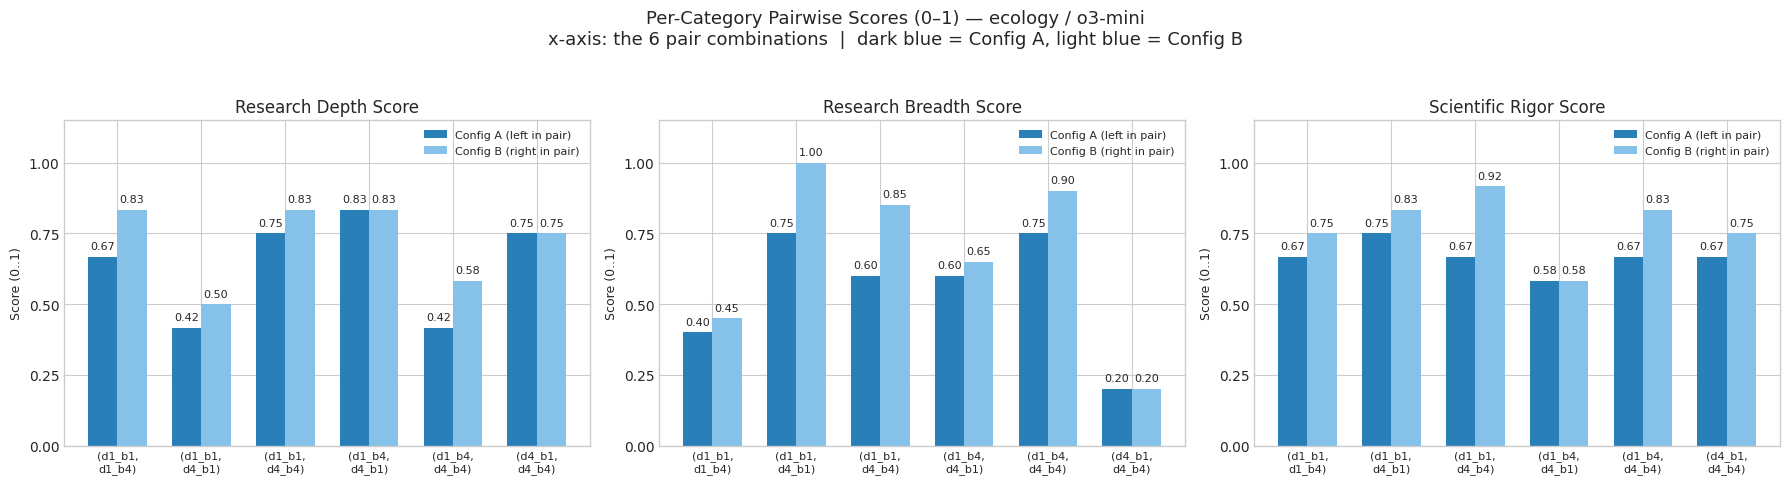

📊 Per-category pairwise score plot rendered
💾 Per-category plot → /nfs/home/gillm/deep-research/eval/output/pairwise_scores_per_category_nlp.png


In [16]:
# ── §7: Per-Category Pairwise Score Plots ────────────────────────────────────
# x-axis  : the 6 pair combinations in canonical order
# y-axis  : normalised score (0..1) from category_scores
# bars    : two per pair — Config A (dark blue) and Config B (light blue)
# panels  : one per active category (depth / breadth / rigor)

import numpy as np
import matplotlib.pyplot as plt

RAW_DIMS = ['depth', 'breadth', 'rigor']
# RAW_DIMS = ['depth', 'breadth', 'rigor', 'innovation', 'gap']  # uncomment when available

RAW_PANEL_TITLES = {
    'depth':   'Research Depth Score',
    'breadth': 'Research Breadth Score',
    'rigor':   'Scientific Rigor Score',
    # 'innovation': 'Innovation Score',
    # 'gap':        'Research Gap Score',
}

# Same color palette as §8b
BAR_COLOR_A = '#2980b9'   # dark blue  — Config A
BAR_COLOR_B = '#85c1e9'   # light blue — Config B

ALL_CONFIGS = list(REPORT_POOL.keys())
ALL_PAIRS   = list(itertools.combinations(ALL_CONFIGS, 2))

# ── 1. Build per-dim data: (score_a, score_b) per pair ───────────────────────
dim_pair_data = {dim: [] for dim in RAW_DIMS}

for cfg_a, cfg_b in ALL_PAIRS:
    pair_key = f'{cfg_a}_vs_{cfg_b}'
    cat_scores = all_pair_results[pair_key]['category_scores']
    for dim in RAW_DIMS:
        scores = cat_scores.get(dim, {'a': 0.0, 'b': 0.0})
        dim_pair_data[dim].append((scores['a'], scores['b']))

# ── 2. Plot ───────────────────────────────────────────────────────────────────
n_dims    = len(RAW_DIMS)
n_pairs   = len(ALL_PAIRS)   # 6
xs_pairs  = np.arange(n_pairs)
BAR_W_RAW = 0.35

n_cols_raw = min(3, n_dims)
n_rows_raw = int(np.ceil(n_dims / n_cols_raw))

plt.style.use('seaborn-v0_8-whitegrid')
fig_raw, axes_raw = plt.subplots(
    n_rows_raw, n_cols_raw,
    figsize=(6 * n_cols_raw, 5 * n_rows_raw),
    squeeze=False,
)
axes_raw_flat = axes_raw.ravel()

for pi, dim in enumerate(RAW_DIMS):
    ax = axes_raw_flat[pi]
    panel_title = RAW_PANEL_TITLES[dim]
    pair_data   = dim_pair_data[dim]

    scores_a = [d[0] for d in pair_data]
    scores_b = [d[1] for d in pair_data]

    ax.bar(
        xs_pairs - BAR_W_RAW / 2, scores_a,
        width=BAR_W_RAW, color=BAR_COLOR_A, label='Config A (left in pair)',
    )
    ax.bar(
        xs_pairs + BAR_W_RAW / 2, scores_b,
        width=BAR_W_RAW, color=BAR_COLOR_B, label='Config B (right in pair)',
    )

    # Value labels
    for x, va, vb in zip(xs_pairs, scores_a, scores_b):
        if va:
            ax.text(x - BAR_W_RAW / 2, va + 0.02, f'{va:.2f}',
                    ha='center', va='bottom', fontsize=8)
        if vb:
            ax.text(x + BAR_W_RAW / 2, vb + 0.02, f'{vb:.2f}',
                    ha='center', va='bottom', fontsize=8)

    tick_labels = [f'({a},\n{b})' for a, b in ALL_PAIRS]
    ax.set_xticks(list(xs_pairs))
    ax.set_xticklabels(tick_labels, fontsize=8)

    ax.set_ylim(0, 1.15)
    ax.set_yticks([0.0, 0.25, 0.5, 0.75, 1.0])
    ax.set_ylabel('Score (0..1)', fontsize=9)
    ax.set_title(panel_title, fontsize=12)
    ax.legend(fontsize=8, loc='upper right')

# Hide spare axes
for j in range(pi + 1, len(axes_raw_flat)):
    axes_raw_flat[j].set_visible(False)

fig_raw.suptitle(
    f'Per-Category Pairwise Scores (0–1) — {DOMAIN} / {engine_str}\n'
    f'x-axis: the 6 pair combinations  |  dark blue = Config A, light blue = Config B',
    fontsize=13,
)
fig_raw.tight_layout(rect=[0, 0.02, 1, 0.94])
plt.show()
print('📊 Per-category pairwise score plot rendered')

# Optional: save
raw_fig_path = Path(OUTPUT_DIR) / f'pairwise_scores_per_category_{DOMAIN}.png'
fig_raw.savefig(raw_fig_path, dpi=200, bbox_inches='tight')
print(f'💾 Per-category plot → {raw_fig_path}')


## 8 — Final Evaluation Output (JSON)

Prints the full results dict covering all 6 pairs.

In [17]:
final_output = {
    'domain':       DOMAIN,
    'report_number': report_num,
    'question':     question,
    'model':        MODEL_ID,
    'pairs':        all_pair_results,   # keyed by 'cfg_a_vs_cfg_b'
}
display(Markdown('---\n### 🏁 Final Output\n---'))
print(json.dumps(final_output, indent=2, ensure_ascii=False))

---
### 🏁 Final Output
---

{
  "domain": "nlp",
  "report_number": 1,
  "question": "What is the effect of management extensification on grasslands plant diversity?",
  "model": "Qwen/Qwen3-8B",
  "pairs": {
    "d1_b1_vs_d1_b4": {
      "config_a": "d1_b1",
      "config_b": "d1_b4",
      "rubric_scores": {
        "TemporalPrecision": {
          "ResponseA": {
            "rating": 3,
            "rationale": "The response includes specific time frames like 'three decades' but also uses vague terms like 'long-term' and 'long-term planning' without further specification."
          },
          "ResponseB": {
            "rating": 4,
            "rationale": "The response provides specific durations such as '30+ years' and a precise date, enhancing temporal clarity and bounded intervals."
          },
          "weight_in": {
            "depth": 0.3333333333333333
          }
        },
        "CausalReasoning": {
          "ResponseA": {
            "rating": 4,
            "rationale": "Response A demonst

## 8b — Aggregated Per-Config Scores (Pointwise-Style Plot)

Each config appears in **3 out of 6 pairs**. Here we collect all the scores a config
receives across every pair it participates in and compute the **mean ± std** for each
dimension. The resulting single chart mirrors the pointwise evaluation layout,
with one bar per config per dimension.

> `innovation` and `gap` are commented out until those rubrics are released in the
> YESciEval package.

Aggregated scores (mean ± std across pairs):
  d1_b1:
    depth         0.611 ± 0.142
    breadth       0.583 ± 0.143
    rigor         0.694 ± 0.039
    overall       0.630 ± 0.039
  d1_b4:
    depth         0.694 ± 0.196
    breadth       0.600 ± 0.122
    rigor         0.667 ± 0.068
    overall       0.654 ± 0.030
  d4_b1:
    depth         0.694 ± 0.142
    breadth       0.617 ± 0.327
    rigor         0.694 ± 0.104
    overall       0.669 ± 0.099
  d4_b4:
    depth         0.722 ± 0.104
    breadth       0.650 ± 0.319
    rigor         0.833 ± 0.068
    overall       0.735 ± 0.125


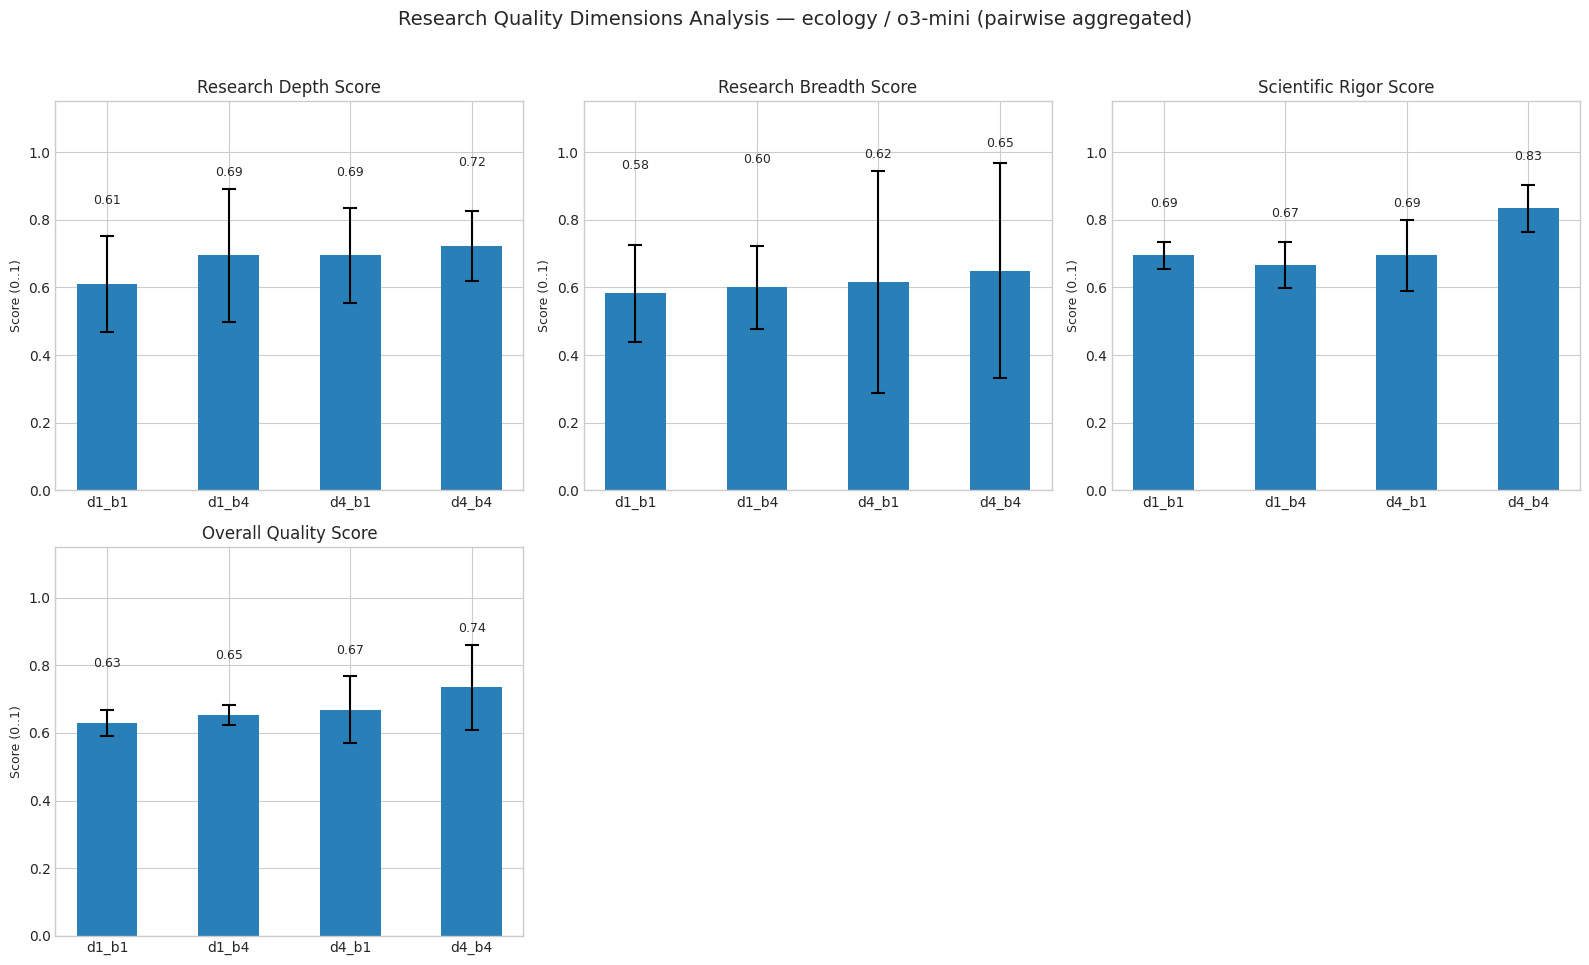

💾 Aggregated plot → /nfs/home/gillm/deep-research/eval/output/pairwise_aggregated_quality_dimensions_nlp.png


In [18]:
from collections import defaultdict
import numpy as np
import matplotlib.pyplot as plt

# ── 1. Dimensions to aggregate (comment out innovation/gap until released) ────
AGG_DIMS = ['depth', 'breadth', 'rigor']
# AGG_DIMS = ['depth', 'breadth', 'rigor', 'innovation', 'gap']  # uncomment when available

PANEL_TITLES_AGG = {
    'depth':      'Research Depth Score',
    'breadth':    'Research Breadth Score',
    'rigor':      'Scientific Rigor Score',
    # 'innovation': 'Innovation Score',       # not yet in yescieval
    # 'gap':        'Research Gap Score',     # not yet in yescieval
    'overall':    'Overall Quality Score',
}

# ── 2. Collect per-config scores from every pair ───────────────────────────────
# config_dim_scores[cfg][dim] = list of scores (one per pair the config appeared in)
config_dim_scores: dict = defaultdict(lambda: defaultdict(list))

for pair_key, res in all_pair_results.items():
    cfg_a = res['config_a']
    cfg_b = res['config_b']
    cat_scores = res['category_scores']
    overall_a  = res['overall_a']
    overall_b  = res['overall_b']

    for dim in AGG_DIMS:
        if dim in cat_scores:
            config_dim_scores[cfg_a][dim].append(cat_scores[dim]['a'])
            config_dim_scores[cfg_b][dim].append(cat_scores[dim]['b'])

    config_dim_scores[cfg_a]['overall'].append(overall_a)
    config_dim_scores[cfg_b]['overall'].append(overall_b)

# ── 3. Compute mean and std per config per dimension ──────────────────────────
# agg[cfg][dim] = (mean, std)
agg: dict = {}
for cfg in ALL_CONFIGS:
    agg[cfg] = {}
    for dim in list(PANEL_TITLES_AGG.keys()):
        vals = config_dim_scores[cfg].get(dim, [])
        if vals:
            agg[cfg][dim] = (float(np.mean(vals)), float(np.std(vals)))
        else:
            agg[cfg][dim] = (0.0, 0.0)

print('Aggregated scores (mean ± std across pairs):')
for cfg in ALL_CONFIGS:
    print(f'  {cfg}:')
    for dim, (mu, sd) in agg[cfg].items():
        print(f'    {dim:12s}  {mu:.3f} ± {sd:.3f}')

# ── 4. Plot ───────────────────────────────────────────────────────────────────
n_panels   = len(PANEL_TITLES_AGG)
n_cols     = 3
n_rows     = int(np.ceil(n_panels / n_cols))
BAR_W_AGG  = 0.18
xs_agg     = np.arange(len(ALL_CONFIGS))

plt.style.use('seaborn-v0_8-whitegrid')
fig_agg, axes_agg = plt.subplots(n_rows, n_cols, figsize=(16, 5 * n_rows))
axes_agg = np.array(axes_agg).ravel()

# Use the same blue palette as the pointwise plot
BAR_COLOR = '#2980b9'
ERR_COLOR = 'black'

for i, (dim, panel_title) in enumerate(PANEL_TITLES_AGG.items()):
    ax   = axes_agg[i]
    means = [agg[cfg][dim][0] for cfg in ALL_CONFIGS]
    stds  = [agg[cfg][dim][1] for cfg in ALL_CONFIGS]

    bars = ax.bar(
        xs_agg, means,
        width=0.5,
        color=BAR_COLOR,
        yerr=stds,
        capsize=5,
        error_kw=dict(ecolor=ERR_COLOR, lw=1.5, capthick=1.5),
    )

    for x, mu in zip(xs_agg, means):
        if mu:
            ax.text(x, mu + max(stds) + 0.03, f'{mu:.2f}',
                    ha='center', va='bottom', fontsize=9)

    ax.set_title(panel_title, fontsize=12)
    ax.set_xticks(list(xs_agg))
    ax.set_xticklabels(ALL_CONFIGS, fontsize=10)
    ax.set_ylim(0, 1.15)
    ax.set_ylabel('Score (0..1)', fontsize=9)

# Hide any spare axes
for j in range(i + 1, len(axes_agg)):
    axes_agg[j].set_visible(False)

fig_agg.suptitle(
    f'Research Quality Dimensions Analysis — {DOMAIN} / {engine_str} (pairwise aggregated)',
    fontsize=14,
)
fig_agg.tight_layout(rect=[0, 0.02, 1, 0.96])
plt.show()

# ── 5. Optional: save the aggregated plot ─────────────────────────────────────
agg_fig_path = Path(OUTPUT_DIR) / f'pairwise_aggregated_quality_dimensions_{DOMAIN}.png'
fig_agg.savefig(agg_fig_path, dpi=200, bbox_inches='tight')
print(f'💾 Aggregated plot → {agg_fig_path}')


## 9 — Save Outputs to Disk

One JSON, one CSV row, and one plot image are saved **per pair**.

In [19]:
out_dir = Path(OUTPUT_DIR)
out_dir.mkdir(parents=True, exist_ok=True)

# ── CSV: one row per pair, all pairs in a single file ────────────────────────
csv_path = out_dir / f'pairwise_all_scores_{DOMAIN}.csv'
csv_rows = []
for pair_key, res in all_pair_results.items():
    row = {
        'pair':      pair_key,
        'config_a':  res['config_a'],
        'config_b':  res['config_b'],
        'question':  question,
    }
    for cat, scores in res['category_scores'].items():
        row[f'{cat}_score_a'] = round(scores['a'], 4)
        row[f'{cat}_score_b'] = round(scores['b'], 4)
    row['overall_score_a'] = round(res['overall_a'], 4)
    row['overall_score_b'] = round(res['overall_b'], 4)
    csv_rows.append(row)

with csv_path.open('w', newline='', encoding='utf-8') as f:
    w = csv.DictWriter(f, fieldnames=list(csv_rows[0].keys()))
    w.writeheader()
    w.writerows(csv_rows)
print(f"💾 CSV   → {csv_path}")

# ── JSON + plot: one file per pair ───────────────────────────────────────────
for pair_key, res in all_pair_results.items():
    pair_output = {
        'domain':          DOMAIN,
        'report_number':   report_num,
        'question':        question,
        'model':           MODEL_ID,
        **res,
    }
    json_path = out_dir / f'{pair_key}_scores.json'
    json_path.write_text(json.dumps(pair_output, indent=2, ensure_ascii=False), encoding='utf-8')
    print(f"💾 JSON  → {json_path}")

    fig_path = out_dir / f'{pair_key}_quality_dimensions.png'
    pair_figs[pair_key].savefig(fig_path, dpi=200, bbox_inches='tight')
    print(f"💾 Plot  → {fig_path}")

💾 CSV   → /nfs/home/gillm/deep-research/eval/output/pairwise_all_scores_nlp.csv
💾 JSON  → /nfs/home/gillm/deep-research/eval/output/d1_b1_vs_d1_b4_scores.json


NameError: name 'pair_figs' is not defined